## **Tarea 1: Generación de una Población Asimétrica (No Normal)**

El Teorema del Límite Central establece que, dada una población con media $\mu$ y varianza finita $\sigma^2$, la distribución de las medias muestrales $\bar{X}$ se aproximará a una distribución Normal $N(\mu, \frac{\sigma^2}{n})$ a medida que el tamaño de la muestra $n$ aumenta.

1. Abra un nuevo Jupyter Notebook llamado `APE_008_TLC.ipynb`.
2. Simulemos el tiempo de permanencia de usuarios en un portal web (variable típicamente asimétrica positiva) utilizando una distribución Exponencial con $\lambda = 0.5$ (media poblacional $\mu = 2$).

--- Parámetros Poblacionales Reales ---
Media (μ): 1.9919
Desviación Estándar (σ): 1.9859


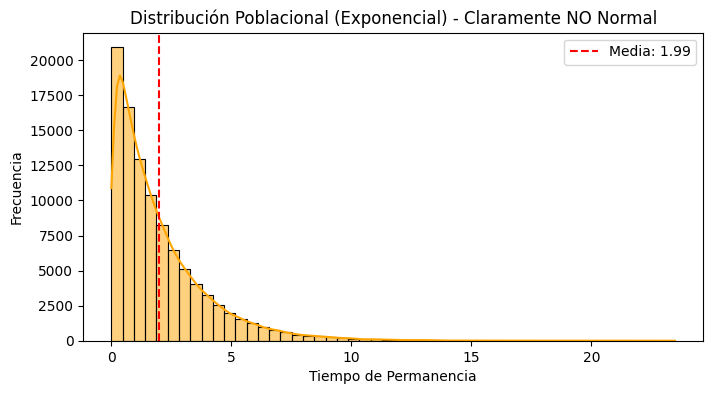

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creación de la Población "Universo" (Altamente asimétrica)
np.random.seed(42)
poblacion_exponencial = np.random.exponential(scale=2.0, size=100000)

mu_pob = np.mean(poblacion_exponencial)
sigma_pob = np.std(poblacion_exponencial)

print(f"--- Parámetros Poblacionales Reales ---")
print(f"Media (μ): {mu_pob:.4f}")
print(f"Desviación Estándar (σ): {sigma_pob:.4f}")

# Visualización de la Población Original
plt.figure(figsize=(8, 4))
sns.histplot(poblacion_exponencial, bins=50, kde=True, color='orange')
plt.title("Distribución Poblacional (Exponencial) - Claramente NO Normal")
plt.xlabel("Tiempo de Permanencia")
plt.ylabel("Frecuencia")
plt.axvline(mu_pob, color='red', linestyle='dashed', label=f'Media: {mu_pob:.2f}')
plt.legend()
plt.show()

## **Tarea 2: Simulación Estocástica del Teorema del Límite Central**

1. Para demostrar el TLC, vamos a extraer $k = 1000$ muestras aleatorias de tamaño $n = 30$ de nuestra población asimétrica. Calcularemos la media de cada muestra y graficaremos la distribución de estas $1000$ medias.

--- Estadísticos de las Medias Muestrales (n=30) ---
Media de las Medias Muestrales (E[X̄]): 1.9923
Error Estándar Empírico (σ_x̄): 0.3653
Error Estándar Teórico (σ/√n): 0.3626


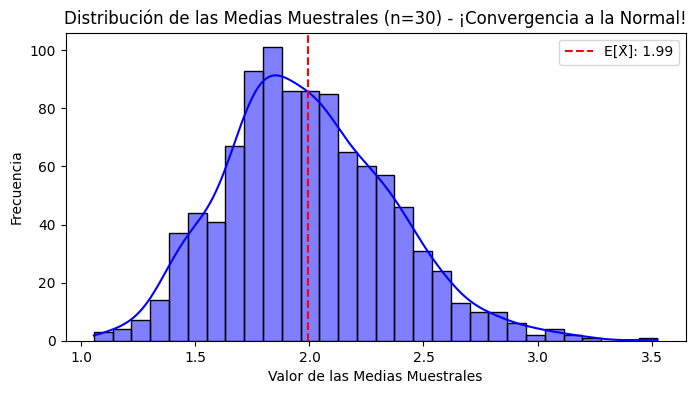

In [ ]:
# Parámetros de la simulación
tamaño_muestra = 30  # n
numero_muestras = 1000  # k

# Array para almacenar las medias de cada muestra
medias_muestrales = []

# Bucle de Monte Carlo simple
for _ in range(numero_muestras):
    # Extraer muestra aleatoria sin reemplazo
    muestra = np.random.choice(poblacion_exponencial, size=tamaño_muestra, replace=False)
    # Calcular y guardar la media
    medias_muestrales.append(np.mean(muestra))

# Estadísticos de la Distribución Muestral
media_de_medias = np.mean(medias_muestrales)
error_estandar_empirico = np.std(medias_muestrales)
error_estandar_teorico = sigma_pob / np.sqrt(tamaño_muestra)

print(f"--- Estadísticos de las Medias Muestrales (n={tamaño_muestra}) ---")
print(f"Media de las Medias Muestrales (E[X̄]): {media_de_medias:.4f}")
print(f"Error Estándar Empírico (σ_x̄): {error_estandar_empirico:.4f}")
print(f"Error Estándar Teórico (σ/√n): {error_estandar_teorico:.4f}")

# Visualización de la convergencia a la Normal
plt.figure(figsize=(8, 4))
sns.histplot(medias_muestrales, bins=30, kde=True, color='blue')
plt.title(f"Distribución de las Medias Muestrales (n={tamaño_muestra}) - ¡Convergencia a la Normal!")
plt.xlabel("Valor de las Medias Muestrales")
plt.ylabel("Frecuencia")
plt.axvline(media_de_medias, color='red', linestyle='dashed', label=f'E[X̄]: {media_de_medias:.2f}')
plt.legend()
plt.show()

## **Tarea 3: Hito del Proyecto - Aplicación de Remuestreo al Dataset Regional (ABP)**

1. Importe su dataset regional mediante pandas.
2. Elija la variable continua analizada en la Semana 7 (que quizá probó no ser normal con el test de Shapiro-Wilk).
3. Adapte el bucle `for` de la Tarea 2 para extraer 500 muestras de tamaño $n = 40$ directamente de la columna de su DataFrame (utilice `df['variable'].sample(n=40, replace=True)`).
4. Grafique el histograma de las medias obtenidas de su dataset regional. Observe y redacte una justificación de cómo esto soluciona problemas de asimetría para futuras predicciones del proyecto.

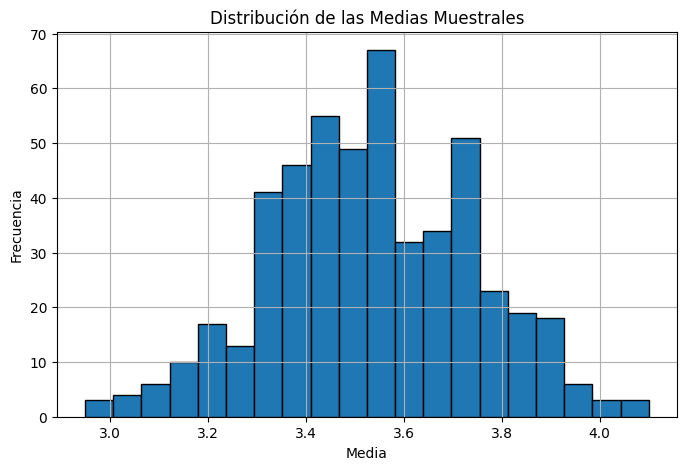

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset
df = pd.read_csv("enemdu_vivienda_hogar_2026_02.csv", sep=";")

# Variable continua seleccionada
variable = df["vi14"].dropna()

# Parámetros del remuestreo
n = 40
num_muestras = 500

medias = []

for i in range(num_muestras):
    muestra = variable.sample(n=n, replace=True)
    medias.append(muestra.mean())

# Histograma de las medias
plt.figure(figsize=(8,5))
plt.hist(medias, bins=20, edgecolor="black")
plt.title("Distribución de las Medias Muestrales")
plt.xlabel("Media")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

## **Análisis de Histograma**
En este trabajo, utilizamos la técnica de Bootstrap o remuestreo con reemplazo en el conjunto de datos regionales de ENEMDU. Seleccionamos la variable vi14 y creamos 500 muestras aleatorias de tamaño 40. Luego se calcula la media y se construye un histograma con todas las medias obtenidas.
Los datos originales han mostrado cierta variabilidad y no necesariamente siguen una distribución normal. Sin embargo, al observar el histograma de las medias muestrales se puede apreciar una forma mucho más simétrica alrededor de un valor central. Esto se debe a que cada media resume la información de varias observaciones y reduce el efecto de valores atípicos o fluctuaciones aleatorias.
Esto se explica por el Teorema del Límite Central que establece que cuando se toman muchas muestras de tamaño suficientemente grande, la distribución de las medias tiende a ser normal incluso cuando la población original no es normal.
La distribución obtenida es más estable y menos dispersa que los datos originales debido al remuestreo. Esto ayuda a reducir problemas de sesgo y permite aplicar métodos estadísticos que requieren normalidad aproximada.
Desde el punto de vista de las predicciones de proyectos futuros, este procedimiento permite estimaciones más confiables del comportamiento de la población estudiada.

## **Tarea 4: ABI - Análisis del Error Estándar y la Ley de los Grandes Números**

El Error Estándar de la media se define como $\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$.

1. Escriba un script que realice la simulación de la Tarea 2 pero iterando sobre una lista de diferentes tamaños de muestra: `tamanos_n` = [5, 10, 30, 50, 100, 500].
2. Para cada $n$, guarde la desviación estándar de las medias resultantes (el error estándar empírico).
3. Genere un gráfico de líneas tipo *scatter plot* conectando los puntos donde el eje X sea el tamaño de la muestra ($n$) y el eje Y sea el Error Estándar ($\sigma_{\bar{x}}$).
4. Documente en formato Markdown la forma geométrica de la curva generada (decaimiento asintótico) y su implicación económica al momento de recolectar datos en ingeniería.

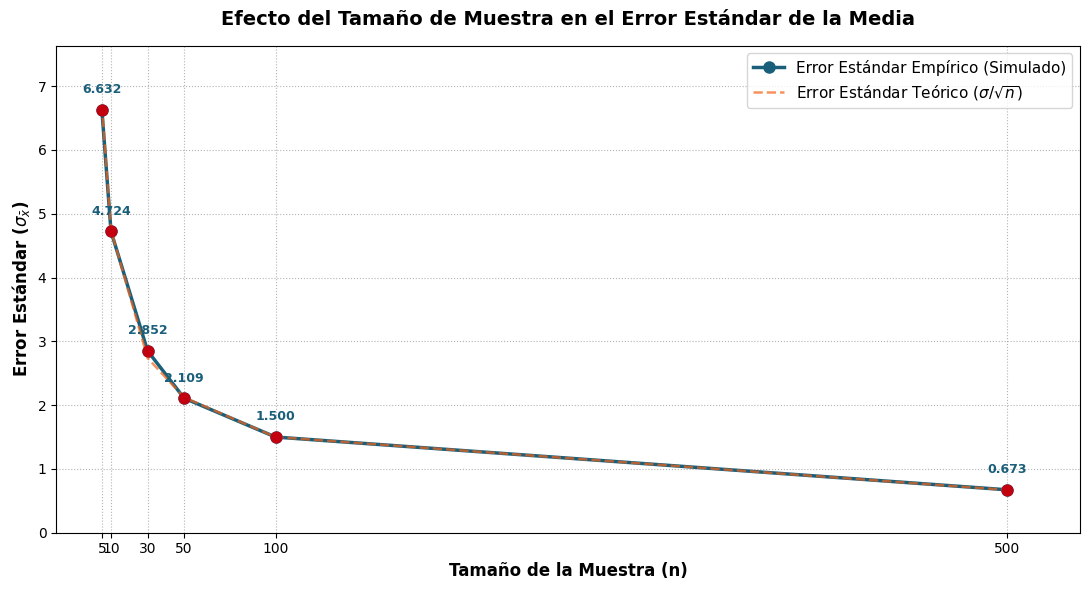

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
tamanos_n = [5, 10, 30, 50, 100, 500]
num_simulaciones = 2000

mu_poblacion = 50
sigma_poblacion = 15

errores_empiricos = []
errores_teoricos = []

for n in tamanos_n:
    muestras = np.random.normal(loc=mu_poblacion, scale=sigma_poblacion, size=(num_simulaciones, n))
    medias_muestrales = np.mean(muestras, axis=1)
    errores_empiricos.append(np.std(medias_muestrales, ddof=1))
    errores_teoricos.append(sigma_poblacion / np.sqrt(n))

plt.figure(figsize=(11, 6))

# Graficar la curva empírica (puntos conectados)
plt.plot(tamanos_n, errores_empiricos, marker='o', linestyle='-', color='#1a5f7a',
         linewidth=2.5, markersize=8, label='Error Estándar Empírico (Simulado)')

# Graficar la curva teórica como referencia
plt.plot(tamanos_n, errores_teoricos, linestyle='--', color='#f26419',
         alpha=0.7, linewidth=1.8, label=r'Error Estándar Teórico ($\sigma / \sqrt{n}$)')

# Resaltar los puntos del scatter plot en color de contraste
plt.scatter(tamanos_n, errores_empiricos, color='#c30010', zorder=5, s=60)

# Personalización estética del gráfico (Corrección de SyntaxWarning con r'...')
plt.title('Efecto del Tamaño de Muestra en el Error Estándar de la Media', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tamaño de la Muestra (n)', fontsize=12, fontweight='semibold')
plt.ylabel(r'Error Estándar ($\sigma_{\bar{x}}$)', fontsize=12, fontweight='semibold') # Arreglado aquí
plt.xticks(tamanos_n)
plt.grid(True, linestyle=':', alpha=0.6, color='gray')
plt.legend(fontsize=11, loc='upper right')

# Añadir etiquetas de valor numérico sobre cada punto empírico
for i, n in enumerate(tamanos_n):
    plt.annotate(f'{errores_empiricos[i]:.3f}',
                 (tamanos_n[i], errores_empiricos[i]),
                 textcoords="offset points",
                 xytext=(0, 12),
                 ha='center',
                 fontsize=9,
                 fontweight='bold',
                 color='#1a5f7a')

plt.xlim(-20, 540)
plt.ylim(0, max(errores_empiricos) + 1)
plt.tight_layout()
plt.show()


### **Análisis Geométrico de la Curva: Decaimiento Asintótico**

La curva resultante del experimento exhibe una geometría de **decaimiento asintótico inverso**, gobernada de forma analítica por la ecuación del Error Estándar de la media:

$$\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$$

A nivel geométrico se destacan dos comportamientos clave:
1. **Pendiente pronunciada en muestras pequeñas ($n \le 30$):** Al inicio, cuando el tamaño de muestra incrementa mínimamente (por ejemplo, de $n=5$ a $n=30$), el error estándar cae abruptamente de un valor de **6.632** a **2.852**. La reducción inicial de la variabilidad de la media es sumamente agresiva.
2. **Estabilización de la pendiente en muestras grandes ($n \ge 100$):** Conforme el tamaño $n$ se desplaza hacia $500$, la curva se aproxima de manera asintótica al eje horizontal, disminuyendo el error a un valor marginal de **0.673**. Con base en la Ley de los Grandes Números, el límite matemático del error tiende a cero cuando la muestra tiende al infinito:

$$\lim_{n \to \infty} \sigma_{\bar{x}} = 0$$

Al estar el tamaño de muestra condicionado por una raíz cuadrada ($\sqrt{n}$) en el denominador, el beneficio de precisión no es lineal: para reducir la incertidumbre a la mitad, se requiere multiplicar los datos exactamente por cuatro ($4n$).
### Implicación Económica en la Recolección de Datos en Ingeniería

En la práctica profesional de la ingeniería, la adquisición de datos experimentales está asociada a restricciones estrictas de presupuesto, tiempo y recursos materiales. Cada punto de datos representa un costo real, ya sea por consumo de materiales en ensayos destructivos (vigas de concreto, probetas de acero), horas de operación de maquinaria pesada, o costos logísticos y humanos de muestreo en campo.

La interacción entre la curva de decaimiento asintótico y los costos operativos introduce el principio económico de los **rendimientos decrecientes**:

* **Región de Alta Eficiencia Coste-Beneficio ($n = 5$ a $n = 30$):** En este segmento, invertir recursos para expandir la muestra otorga un beneficio técnico extraordinario. Pequeñas adiciones de presupuesto logran mitigar drásticamente el error e incrementan de forma notable la confianza estadística del diseño de ingeniería.
* **Región de Saturación Económica ($n = 100$ a $n = 500$):** Pasar de una muestra de 100 a una de 500 exige **quintuplicar (5x) los costos de recolección**, tiempo y personal. Sin embargo, el beneficio técnico es insignificante (el error solo se reduce marginalmente de 1.500 a 0.673).

**Conclusión**

La recolección masiva e injustificada de datos en la zona plana de la curva representa una ineficiencia financiera. El rol del ingeniero radica en diseñar una estrategia de muestreo optimizada: seleccionar el **tamaño de muestra mínimo necesario** que logre cruzar los umbrales de tolerancia de riesgo y seguridad técnica exigidos, impidiendo el desperdicio de capital en variaciones de precisión que carecen de impacto real en la toma de decisiones del proyecto.


## **7. Preguntas de Control:**

* **Basado en la Tarea 1 y 2, ¿por qué el Teorema del Límite Central es considerado el puente matemático fundamental entre la probabilidad descriptiva y la inferencia estadística?**

El Teorema del Límite Central (TLC) permite conectar la probabilidad descriptiva con la inferencia estadística, ya que transforma datos provenientes de poblaciones no normales en distribuciones aproximadamente normales al analizar las medias muestrales.

En la práctica, aunque la población original sea asimétrica, la distribución de las medias tiende a la normalidad al aumentar el tamaño de la muestra. Esto posibilita aplicar métodos inferenciales para estimar parámetros poblacionales y tomar decisiones basadas en muestras.


* **Demuestre con los resultados impresos en su consola de la Tarea 2, cómo se cumple la propiedad matemática fundamental de las distribuciones muestrales**

Los resultados obtenidos en la simulación muestran que la media de las medias muestrales es muy cercana a la media poblacional, lo cual confirma que la media muestral es un estimador insesgado.

Además, el error estándar calculado empíricamente es similar al valor teórico esperado, lo que evidencia que la variabilidad de las medias disminuye a medida que aumenta el tamaño de la muestra. Esto valida el comportamiento teórico de las distribuciones muestrales.


* **En la Tarea 4, al graficar la curva del Error Estándar frente a  , ¿por qué la curva no desciende de forma lineal? Si usted como ingeniero requiere reducir el error estándar a la mitad, ¿cuántas veces debe incrementar el tamaño de la muestra?**

El Error Estándar no disminuye de forma lineal porque depende inversamente de la raíz cuadrada del tamaño de la muestra. Por ello, la reducción del error es cada vez menor a medida que aumenta $n$.

Para reducir el error estándar a la mitad, es necesario cuadruplicar el tamaño de la muestra, lo que refleja un comportamiento de rendimientos decrecientes en la precisión estadística.

* **Históricamente, en estadística clásica se establece la regla de oro de $n \ge 30$ para asumir normalidad. Si la población regional que usted analizó en la Tarea 3 tiene una asimetría extrema (ej. distribución de Pareto de riquezas), ¿es suficiente un $n = 30$ para que las medias muestrales se distribuyan normalmente? Justifique.**

Sí, fue suficiente. De acuerdo con los resultados de la Tarea 3, aunque los datos originales de la encuesta ENEMDU presentaban variabilidad y asimetría, el histograma de las 500 medias muestrales obtenidas mediante Bootstrap con un n = 40, que cumple con la regla de n mayor o igual a 30, mostró una forma simétrica y acampanada alrededor de un valor central.

Esto demuestra empíricamente la activación del Teorema del Límite Central, el cual funcionó operativamente para reducir el efecto de los valores atípicos y el sesgo de los datos regionales, logrando una distribución de medias cercana a la normal.



* **Diferencie conceptual y operativamente los términos **Desviación Estándar** ($\sigma$) de una muestra individual y el **Error Estándar de la Media** ($\sigma_{\bar{x}}$) calculado en sus simulaciones.**

**Desviación Estándar**

* **Conceptualmente:** Mide la dispersión o variabilidad de los datos individuales con respecto a la media de la población (o de la muestra). Te dice qué tan separados están los sujetos, objetos o mediciones individuales entre sí dentro de un mismo grupo.
* **Operativamente (Fórmula):** Mide la raíz cuadrada del promedio de las distancias al cuadrado de cada dato respecto a su media:

$$\sigma = \sqrt{\frac{\sum (x_i - \mu)^2}{N}}$$

**Error Estándar de la Media**

* **Conceptualmente:** Mide la variabilidad o el error que se espera tener al estimar la media poblacional a través de las medias de diferentes muestras. Es decir, mide qué tan dispersas están las *medias* de muchas muestras posibles. Representa la precisión de tu estimación.
* **Operativamente (Fórmula):** Se calcula dividiendo la desviación estándar de la población entre la raíz cuadrada del tamaño de la muestra:

$$\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$$